In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.basemap import Basemap

from watobs import CMEMSSatObsRepository

import copernicusmarine

# First time users
First time users of the Copernicus Marine API will need to create an account at https://marine.copernicus.eu/ and generate an API key.

Below you call the login function to authenticate your credentials. You only have to do this the first time you use the API on a PC.



In [ ]:
if not CMEMSSatObsRepository.validate_login():
    copernicusmarine.login()

### Specify dataset of product to be downloaded from CMEMS Online Catalogue
- Click through the catalogue here: https://data.marine.copernicus.eu/products?pk_vid=bfd50509683fc0421764148768aca348 

Options are currently:
- "WAVE_GLO_PHY_SWH_L3_MY_014_005" 
- "WAVE_GLO_PHY_SWH_L3_NRT_014_001" 
- "WIND_GLO_PHY_L3_MY_012_005" 
- "WIND_GLO_PHY_L3_NRT_012_002

Ideally there would be a better way to specify this in the future

In [19]:
repo = CMEMSSatObsRepository("WIND_GLO_PHY_L3_NRT_012_002")

Loading CMEMS product id: WIND_GLO_PHY_L3_NRT_012_002
	Done!


In [ ]:
repo.get_observation_stats()

In [ ]:
repo.plot_observation_stats()

### Datasets from product `WIND_GLO_PHY_L3_NRT_012_002`
- A total of 16 datasets, i.e. data from 8 different satellite missions, 2 orbits (asc/desc) each, are available in the catalogue for this product. (32 datasets if you include the coarser resolutions)

In [ ]:
datasets = repo.datasets
datasets.head()

# Lets just choose the first satellite mission for simplicity
- In this case, i am interested in data from 2019 only
- In addition i want to see data in the North Sea west of the Danish coastline

In [ ]:
dataset = repo.dataset_ids[0]

start_time="2021-01-01"
end_time="2021-12-31"

lon_min = 6
lon_max = 9
lat_min = 55
lat_max = 57.5

area = f"bbox={lon_min},{lat_min},{lon_max},{lat_max}"

In [ ]:
df = repo.get_satobs_data(
    dataset_id=dataset, # we can disable this comment to download one dataset at a time
    start_time=start_time,
    end_time=end_time,
    area=area,
)

### Data downloaded
- And it took 25-30 seconds for a year worth of wind speeds, directions and vector components

In [ ]:
df.head()

### Plotting
- Lets plot and see the data

In [ ]:
# Subset
timestep_2_plot = df.index.unique()[1]
df_subset = df.loc[df.index.unique()[1]]

# Define bounding box
dxm = 20
lon_0 = 0.5 * (lon_min + lon_max)
lat_0 = 0.5 * (lat_min + lat_max)

plt.figure(figsize=(10, 6))

# Initialize Basemap
m = Basemap(projection='cyl',
            lon_0=lon_0, lat_0=lat_0,
            llcrnrlon=lon_min, llcrnrlat=lat_min,
            urcrnrlon=lon_max, urcrnrlat=lat_max,
            resolution='l')

# Draw map features
m.drawcoastlines(color='gray', linewidth=0.5)
m.fillcontinents(color='lightgray', lake_color='lightblue')
m.drawmapboundary(fill_color='lightblue')

# Draw parallels and meridians
m.drawparallels(np.arange(lat_min, lat_max + dxm, dxm),
                labels=[1, 0, 0, 0], linewidth=0.5, color='lightgray', dashes=[2, 2])
m.drawmeridians(np.arange(lon_min, lon_max + dxm, dxm),
                labels=[0, 0, 0, 1], linewidth=0.5, color='lightgray', dashes=[2, 2])

# Prepare coordinates
x, y = m(df_subset['longitude'].values, df_subset['latitude'].values)

# Scatter plot with alpha mask
cs = m.scatter(x, y, c=df_subset['WS'], s=15, marker='o',
    cmap=plt.cm.jet, vmin=0, vmax=10)

# Vector plot of wind direction
u = df_subset['WS'] * np.cos(np.radians(df_subset['WD']))
v = df_subset['WS'] * np.sin(np.radians(df_subset['WD']))
norm = plt.Normalize(vmin=0, vmax=10)
m.quiver(x, y, u, v, df_subset['WS'], scale=100,  cmap=plt.cm.jet, norm=norm)

# Colorbar
cbar = m.colorbar(cs, location='bottom', pad="5%")
cbar.set_label('WS')

plt.title(f'Scatter Plot of WS > 0 m/s\n{timestep_2_plot}')
plt.show()

# Repeat 4 SWH


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.basemap import Basemap

from watobs import CMEMSSatObsRepository

import copernicusmarine

In [2]:
repo = CMEMSSatObsRepository("WAVE_GLO_PHY_SWH_L3_NRT_014_001")

Loading CMEMS product id: WAVE_GLO_PHY_SWH_L3_NRT_014_001
	Done!


In [3]:
repo.get_observation_stats()

,min_date,max_date
short_name,,
al,2021-01-01 00:27:03+00:00,2025-12-02 10:48:57+00:00
c2,2021-01-01 00:00:00+00:00,2025-12-02 10:53:12+00:00
cfo,2021-01-01 00:34:11+00:00,2025-12-02 09:25:53+00:00
h2b,2021-01-01 00:00:00+00:00,2025-11-30 22:49:57+00:00
h2c,2022-12-01 01:07:06+00:00,2025-11-30 22:48:25+00:00
j3,2021-01-01 00:08:17+00:00,2025-12-02 10:20:03+00:00
s3a,2021-01-01 00:14:33+00:00,2025-12-02 10:39:17+00:00
s3b,2021-01-01 00:00:39+00:00,2025-12-02 11:38:28+00:00
s6a,2021-09-21 00:02:30+00:00,2025-12-02 12:05:17+00:00


C:\Working\Coding\Repos\watobs\watobs\altimetry.py:297: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  yearly = pd.date_range(start="1984-1-1", end=end_date, freq="2AS")


<Axes: title={'center': 'Satellite lifespan'}>

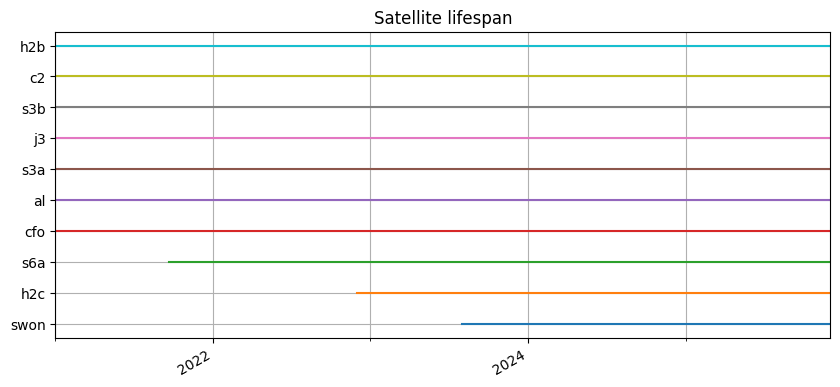

In [4]:
repo.plot_observation_stats()

# Lets just choose the first satellite mission for simplicity
- In this case, i am interested in data from 2019 only
- In addition i want to see data in the North Sea west of the Danish coastline

In [5]:
dataset = repo.dataset_ids[0]

start_time="2021-01-01"
end_time="2021-12-31"

lon_min = 6
lon_max = 9
lat_min = 55
lat_max = 57.5

area = f"bbox={lon_min},{lat_min},{lon_max},{lat_max}"

In [ ]:
df = repo.get_satobs_data(
    #dataset_id=dataset, # we can disable this comment to download one dataset at a time
    start_time=start_time,
    end_time=end_time,
    area=area,
)

-- Downloading subset of cmems_obs-wave_glo_phy-swh_nrt_al-l3_PT1S


INFO - 2025-12-02T14:06:15Z - Selected dataset version: "202211"
INFO - 2025-12-02T14:06:15Z - Selected dataset part: "default"
WARNING - 2025-12-02T14:06:15Z - Some of your subset selection [2021-01-01 00:00:00+00:00, 2021-12-31 00:00:00+00:00] for the time dimension exceed the dataset coordinates [2021-01-01 00:27:03+00:00, 2025-12-02 10:48:57+00:00]


-- Download successful.
<_io.BufferedReader name='c:\\Working\\Coding\\Repos\\watobs\\notebooks\\cmems_6h6tw4g0\\cmems_obs-wave_glo_phy-swh_nrt_al-l3_PT1S_VAVH-VAVH_UNFILTERED-WIND_SPEED_6.00E-9.00E_55.00N-57.50N_2021-01-01-2021-12-31.csv'>
-- Downloading subset of cmems_obs-wave_glo_phy-swh_nrt_c2-l3_PT1S


INFO - 2025-12-02T14:06:30Z - Selected dataset version: "202211"
INFO - 2025-12-02T14:06:30Z - Selected dataset part: "default"

### Data downloaded
- And it took 25-30 seconds for a year worth of wind speeds, directions and vector components

In [11]:
df.head()

,longitude,latitude,SWH,value_qc
time,,,,
2021-01-05 04:26:15,8.749426,57.153362,1.448,1
2021-01-05 04:26:16,8.713835,57.213127,1.510,1
2021-01-05 04:26:17,8.678142,57.272884,1.649,1
2021-01-05 04:26:18,8.642348,57.332630,1.810,1
2021-01-05 04:26:19,8.606452,57.392370,1.943,1


### Plotting
- Lets plot and see the data

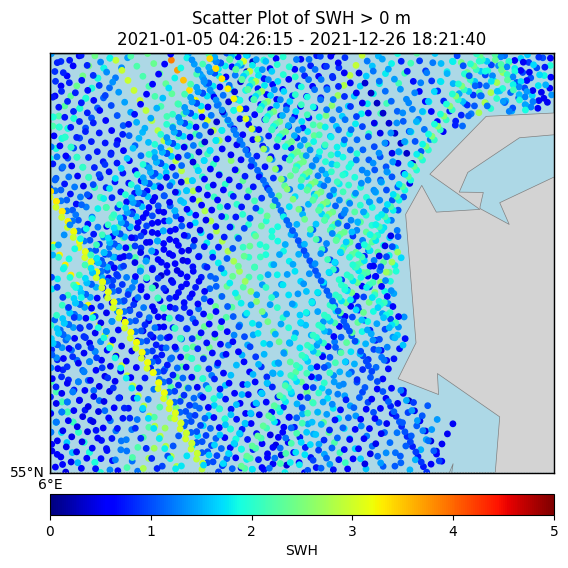

In [18]:
# Subset
timestep_2_plot = df.index.unique()[1]
df_subset = df.copy()

# Define bounding box
dxm = 20
lon_0 = 0.5 * (lon_min + lon_max)
lat_0 = 0.5 * (lat_min + lat_max)

plt.figure(figsize=(10, 6))

# Initialize Basemap
m = Basemap(projection='cyl',
            lon_0=lon_0, lat_0=lat_0,
            llcrnrlon=lon_min, llcrnrlat=lat_min,
            urcrnrlon=lon_max, urcrnrlat=lat_max,
            resolution='l')

# Draw map features
m.drawcoastlines(color='gray', linewidth=0.5)
m.fillcontinents(color='lightgray', lake_color='lightblue')
m.drawmapboundary(fill_color='lightblue')

# Draw parallels and meridians
m.drawparallels(np.arange(lat_min, lat_max + dxm, dxm),
                labels=[1, 0, 0, 0], linewidth=0.5, color='lightgray', dashes=[2, 2])
m.drawmeridians(np.arange(lon_min, lon_max + dxm, dxm),
                labels=[0, 0, 0, 1], linewidth=0.5, color='lightgray', dashes=[2, 2])

# Prepare coordinates
x, y = m(df_subset['longitude'].values, df_subset['latitude'].values)

# Scatter plot with alpha mask
cs = m.scatter(x, y, c=df_subset['SWH'], s=15, marker='o',
    cmap=plt.cm.jet, vmin=0, vmax=5)

# Colorbar
cbar = m.colorbar(cs, location='bottom', pad="5%")
cbar.set_label('SWH')

plt.title(f'Scatter Plot of SWH > 0 m\n{df.index[0]} - {df.index[-1]}')
plt.show()

# One big dataset...
Download the whole globe

In [ ]:
df = repo.download_copernicus_data(dataset_id=dataset,
                                                    start_time="2021-01-01",
                                                    end_time="2021-12-31")

In [ ]:
# Define bounding box
dxm = 20
lon_min = 0
lon_max = 359
lat_min = -90
lat_max = 90
lon_0 = 0.5 * (lon_min + lon_max)
lat_0 = 0.5 * (lat_min + lat_max)

plt.figure(figsize=(10, 6))

# Initialize Basemap
m = Basemap(projection='cyl',
            lon_0=lon_0, lat_0=lat_0,
            llcrnrlon=lon_min, llcrnrlat=lat_min,
            urcrnrlon=lon_max, urcrnrlat=lat_max,
            resolution='l')

# Draw map features
m.drawcoastlines(color='gray', linewidth=0.5)
m.fillcontinents(color='lightgray', lake_color='lightblue')
m.drawmapboundary(fill_color='lightblue')

# Draw parallels and meridians
m.drawparallels(np.arange(lat_min, lat_max + dxm, dxm),
                labels=[1, 0, 0, 0], linewidth=0.5, color='lightgray', dashes=[2, 2])
m.drawmeridians(np.arange(lon_min, lon_max + dxm, dxm),
                labels=[0, 0, 0, 1], linewidth=0.5, color='lightgray', dashes=[2, 2])

# Prepare coordinates
x, y = m(df['longitude'].values, df['latitude'].values)

# Create alpha mask: transparent if WS == 0.5
alpha_values = np.where(df['WS'] < 0.01, 0.0, 1.0)

# Scatter plot with alpha mask
cs = m.scatter(x, y, c=df['WS'], s=1, marker='o',
               cmap=plt.cm.jet, vmin=0, vmax=10,
               alpha=alpha_values)

# Colorbar
cbar = m.colorbar(cs, location='bottom', pad="5%")
cbar.set_label('WS')

plt.title('Scatter Plot of WS > 0 m/s')
plt.show()